# 05 — Visualize Bare Extracted Features with UMAP

This notebook visualizes the **bare extracted features** from notebook 03, without training a classifier.

It will:
1. load each pretrained feature set from `features_npy_large`,
2. choose a split (`train`, `val`, `test`, or `all`),
3. sample a manageable number of points for visualization,
4. optionally standardize the sampled features,
5. run **UMAP**,
6. save the UMAP coordinates and plots.

Use this notebook when you want to inspect the structure of the **raw pretrained features themselves**.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

try:
    import umap
except ImportError:
    raise ImportError("UMAP is not installed. Please run: pip install umap-learn")

# Change this path if your shared folder is different.
PROJECT_ROOT = Path("..")
OUTPUT_DIR = PROJECT_ROOT / "output"

SPLIT_DIR = OUTPUT_DIR / "splits"
FEATURE_DIR = OUTPUT_DIR / "features"
RESULTS_DIR = OUTPUT_DIR / "bare_feature_umap_results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42

# Visualization settings
VISUALIZATION_SOURCE = "test"   # "train", "val", "test", or "all"
MAX_VIS_SAMPLES = 5000
STANDARDIZE_BEFORE_UMAP = True

# UMAP settings
N_NEIGHBORS = 15
MIN_DIST = 0.1
UMAP_METRIC = "euclidean"

# If there are many classes, the plot legend can become unreadable.
MAX_LEGEND_CLASSES = 15

np.random.seed(RANDOM_SEED)

print("Feature directory:", FEATURE_DIR)
print("Result directory:", RESULTS_DIR)
print("Visualization source:", VISUALIZATION_SOURCE)
print("Max visualization samples:", MAX_VIS_SAMPLES)


Feature directory: ..\output\features
Result directory: ..\output\bare_feature_umap_results
Visualization source: test
Max visualization samples: 5000


In [3]:
class_names = np.load(SPLIT_DIR / "class_names.npy", allow_pickle=True)

y_train = np.load(SPLIT_DIR / "y_train_idx.npy", allow_pickle=True)
y_val = np.load(SPLIT_DIR / "y_val_idx.npy", allow_pickle=True)
y_test = np.load(SPLIT_DIR / "y_test_idx.npy", allow_pickle=True)

y_train_names = np.load(SPLIT_DIR / "y_train_names.npy", allow_pickle=True)
y_val_names = np.load(SPLIT_DIR / "y_val_names.npy", allow_pickle=True)
y_test_names = np.load(SPLIT_DIR / "y_test_names.npy", allow_pickle=True)

print("Number of classes:", len(class_names))
print("Train labels:", y_train.shape)
print("Validation labels:", y_val.shape)
print("Test labels:", y_test.shape)


Number of classes: 32
Train labels: (82434,)
Validation labels: (27478,)
Test labels: (27478,)


In [4]:
feature_folders = []

for folder in sorted(FEATURE_DIR.iterdir()):
    if not folder.is_dir():
        continue

    required_files = [
        folder / "train_features.npy",
        folder / "val_features.npy",
        folder / "test_features.npy",
    ]

    if all(path.exists() for path in required_files):
        feature_folders.append(folder)

print("Detected feature folders:")
for folder in feature_folders:
    print("-", folder.name)

if not feature_folders:
    raise FileNotFoundError(
        f"No valid feature folders found in {FEATURE_DIR}. "
        "Run 03_extract_pretrained_features_npy.ipynb first."
    )


Detected feature folders:
- cytoimagenet_efficientnetb0
- densenet121
- efficientnet_b0
- mobilenet_v3_large
- resnet50
- vit_b_16


In [12]:
def random_sample_indices(n_samples, max_samples, random_seed=RANDOM_SEED):
    if n_samples <= max_samples:
        return np.arange(n_samples)
    rng = np.random.default_rng(random_seed)
    return np.sort(rng.choice(n_samples, size=max_samples, replace=False))


def proportional_sample_counts(sizes, max_total):
    total = int(np.sum(sizes))
    if total <= max_total:
        return list(sizes)

    proportions = np.asarray(sizes, dtype=float) / total
    counts = np.floor(proportions * max_total).astype(int)
    counts = np.maximum(counts, 1)

    while counts.sum() > max_total:
        idx = np.argmax(counts)
        if counts[idx] > 1:
            counts[idx] -= 1
        else:
            break

    while counts.sum() < max_total:
        remaining = np.asarray(sizes) - counts
        idx = np.argmax(remaining)
        if remaining[idx] > 0:
            counts[idx] += 1
        else:
            break

    return counts.tolist()


def load_feature_visualization_sample(feature_folder, source="test", max_samples=MAX_VIS_SAMPLES):
    if source not in {"train", "val", "test", "all"}:
        raise ValueError("source must be one of: train, val, test, all")

    split_map = {
        "train": {
            "X": np.load(feature_folder / "train_features.npy", mmap_mode="r"),
            "y_idx": y_train,
            "y_names": y_train_names,
        },
        "val": {
            "X": np.load(feature_folder / "val_features.npy", mmap_mode="r"),
            "y_idx": y_val,
            "y_names": y_val_names,
        },
        "test": {
            "X": np.load(feature_folder / "test_features.npy", mmap_mode="r"),
            "y_idx": y_test,
            "y_names": y_test_names,
        },
    }

    if source in split_map:
        X = split_map[source]["X"]
        labels_idx = split_map[source]["y_idx"]
        labels_names = split_map[source]["y_names"]

        sample_idx = random_sample_indices(len(labels_idx), max_samples)
        sampled_X = np.asarray(X[sample_idx], dtype=np.float32)
        sampled_labels_idx = labels_idx[sample_idx]
        sampled_labels_names = labels_names[sample_idx]
        sampled_splits = np.array([source] * len(sample_idx))

        return sampled_X, sampled_labels_idx, sampled_labels_names, sampled_splits

    split_names = ["train", "val", "test"]
    split_sizes = [len(y_train), len(y_val), len(y_test)]
    sample_counts = proportional_sample_counts(split_sizes, max_samples)

    X_list = []
    y_idx_list = []
    y_name_list = []
    split_list = []

    for split_name, split_count in zip(split_names, sample_counts):
        X = split_map[split_name]["X"]
        labels_idx = split_map[split_name]["y_idx"]
        labels_names = split_map[split_name]["y_names"]

        sample_idx = random_sample_indices(len(labels_idx), split_count)

        X_list.append(np.asarray(X[sample_idx], dtype=np.float32))
        y_idx_list.append(labels_idx[sample_idx])
        y_name_list.append(labels_names[sample_idx])
        split_list.append(np.array([split_name] * len(sample_idx)))

    sampled_X = np.concatenate(X_list, axis=0)
    sampled_labels_idx = np.concatenate(y_idx_list, axis=0)
    sampled_labels_names = np.concatenate(y_name_list, axis=0)
    sampled_splits = np.concatenate(split_list, axis=0)

    return sampled_X, sampled_labels_idx, sampled_labels_names, sampled_splits


def plot_umap_by_label(coords, labels, out_file, title):
    labels = np.asarray(labels)
    unique_labels = np.unique(labels)

    plt.figure(figsize=(12, 8))

    for label in unique_labels:
        mask = labels == label

        plt.scatter(
            coords[mask, 0],
            coords[mask, 1],
            s=12,
            alpha=0.7,
            label=str(label),
        )

    plt.title(title)
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")

    plt.legend(
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        fontsize=8,
        title="Condition",
    )

    plt.tight_layout()
    plt.savefig(out_file, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_umap_by_split(coords, splits, out_file, title):
    unique_splits = np.unique(splits)

    plt.figure(figsize=(10, 8))
    for split_name in unique_splits:
        mask = splits == split_name
        plt.scatter(
            coords[mask, 0],
            coords[mask, 1],
            s=12,
            alpha=0.7,
            label=str(split_name),
        )

    plt.title(title)
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_file, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()


In [13]:
def run_umap_for_feature_folder(
    feature_folder,
    source=VISUALIZATION_SOURCE,
    max_samples=MAX_VIS_SAMPLES,
):
    feature_name = feature_folder.name
    result_dir = RESULTS_DIR / feature_name
    result_dir.mkdir(parents=True, exist_ok=True)

    print("\n" + "=" * 100)
    print("Running bare-feature UMAP for:", feature_name)
    print("=" * 100)

    sampled_X, sampled_labels_idx, sampled_labels_names, sampled_splits = load_feature_visualization_sample(
        feature_folder,
        source=source,
        max_samples=max_samples,
    )

    print("Sampled feature shape:", sampled_X.shape)
    print("Number of sampled classes:", len(np.unique(sampled_labels_idx)))

    if STANDARDIZE_BEFORE_UMAP:
        sampled_X = StandardScaler().fit_transform(sampled_X)
        print("Applied StandardScaler to sampled features.")

    reducer = umap.UMAP(
        n_neighbors=N_NEIGHBORS,
        min_dist=MIN_DIST,
        n_components=2,
        metric=UMAP_METRIC,
        random_state=RANDOM_SEED,
    )

    umap_coords = reducer.fit_transform(sampled_X)

    metadata_df = pd.DataFrame({
        "split": sampled_splits,
        "true_idx": sampled_labels_idx,
        "true_name": sampled_labels_names,
        "umap_x": umap_coords[:, 0],
        "umap_y": umap_coords[:, 1],
    })

    np.save(result_dir / f"bare_features_sample_{source}.npy", sampled_X)
    np.save(result_dir / f"bare_features_umap_{source}.npy", umap_coords)

    metadata_df.to_csv(
        result_dir / f"bare_features_umap_{source}.csv",
        index=False,
    )

    plot_umap_by_label(
        umap_coords,
        sampled_labels_idx,
        result_dir / f"bare_features_umap_{source}_by_label.png",
        title=f"Bare Feature UMAP - {feature_name} - {source} colored by label",
    )

    if source == "all":
        plot_umap_by_split(
            umap_coords,
            sampled_splits,
            result_dir / f"bare_features_umap_{source}_by_split.png",
            title=f"Bare Feature UMAP - {feature_name} - {source} colored by split",
        )

    summary_row = {
        "feature_name": feature_name,
        "source": source,
        "n_samples": len(sampled_labels_idx),
        "n_classes": len(np.unique(sampled_labels_idx)),
        "result_dir": str(result_dir),
    }

    return summary_row


Running bare-feature UMAP for: cytoimagenet_efficientnetb0
Sampled feature shape: (5000, 5120)
Number of sampled classes: 31
Applied StandardScaler to sampled features.


d:\Haohuan\Anaconda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


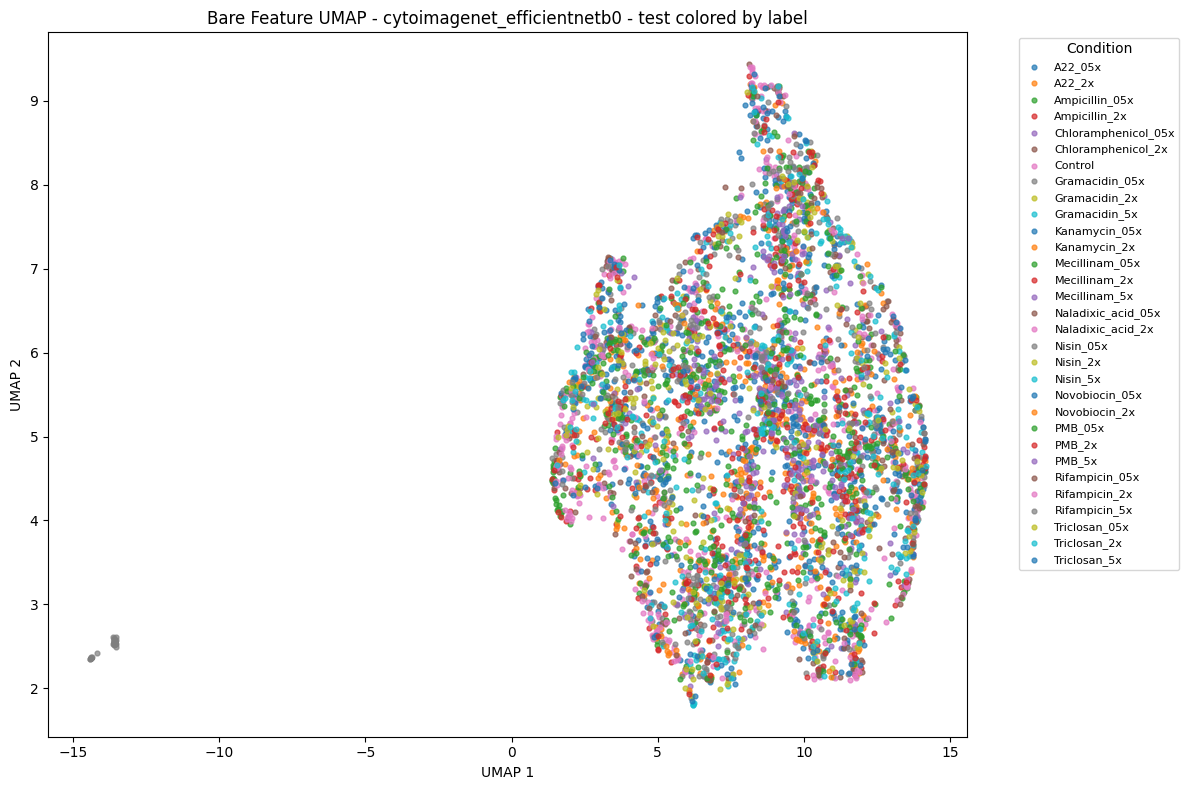


Running bare-feature UMAP for: densenet121
Sampled feature shape: (5000, 4096)
Number of sampled classes: 31
Applied StandardScaler to sampled features.


d:\Haohuan\Anaconda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


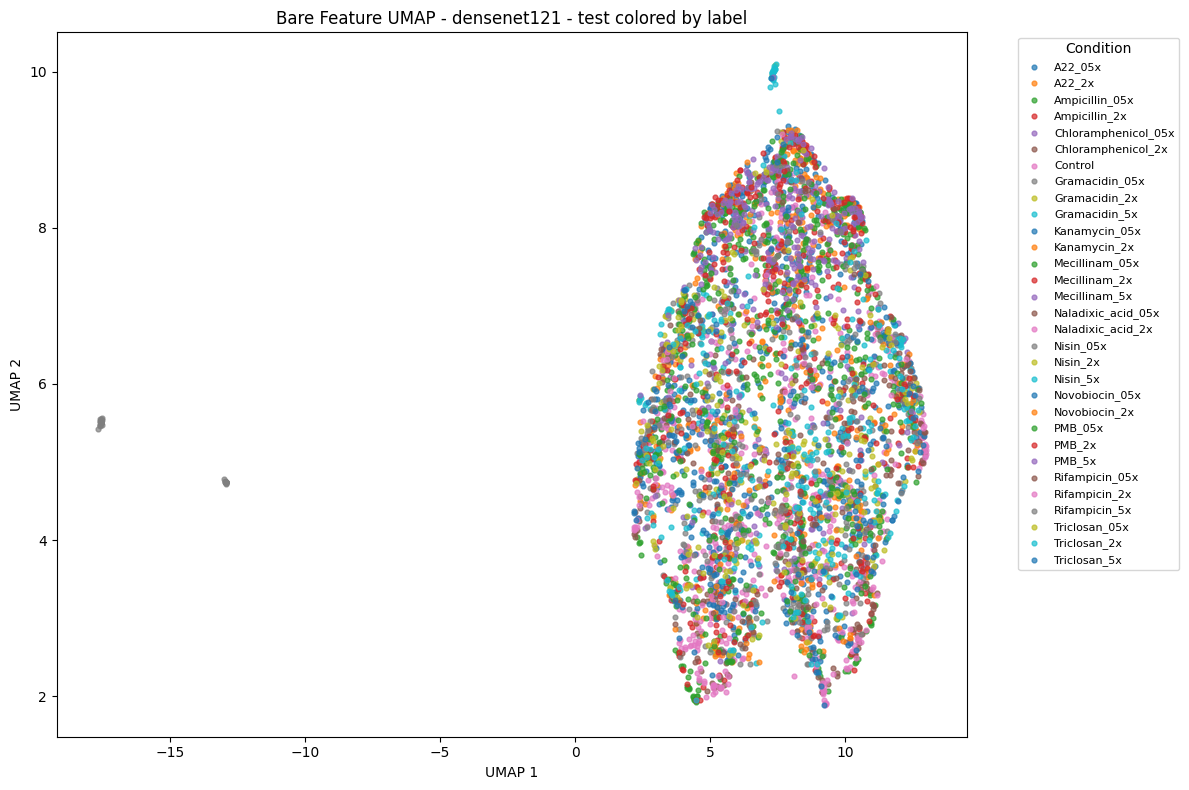


Running bare-feature UMAP for: efficientnet_b0
Sampled feature shape: (5000, 5120)
Number of sampled classes: 31
Applied StandardScaler to sampled features.


d:\Haohuan\Anaconda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


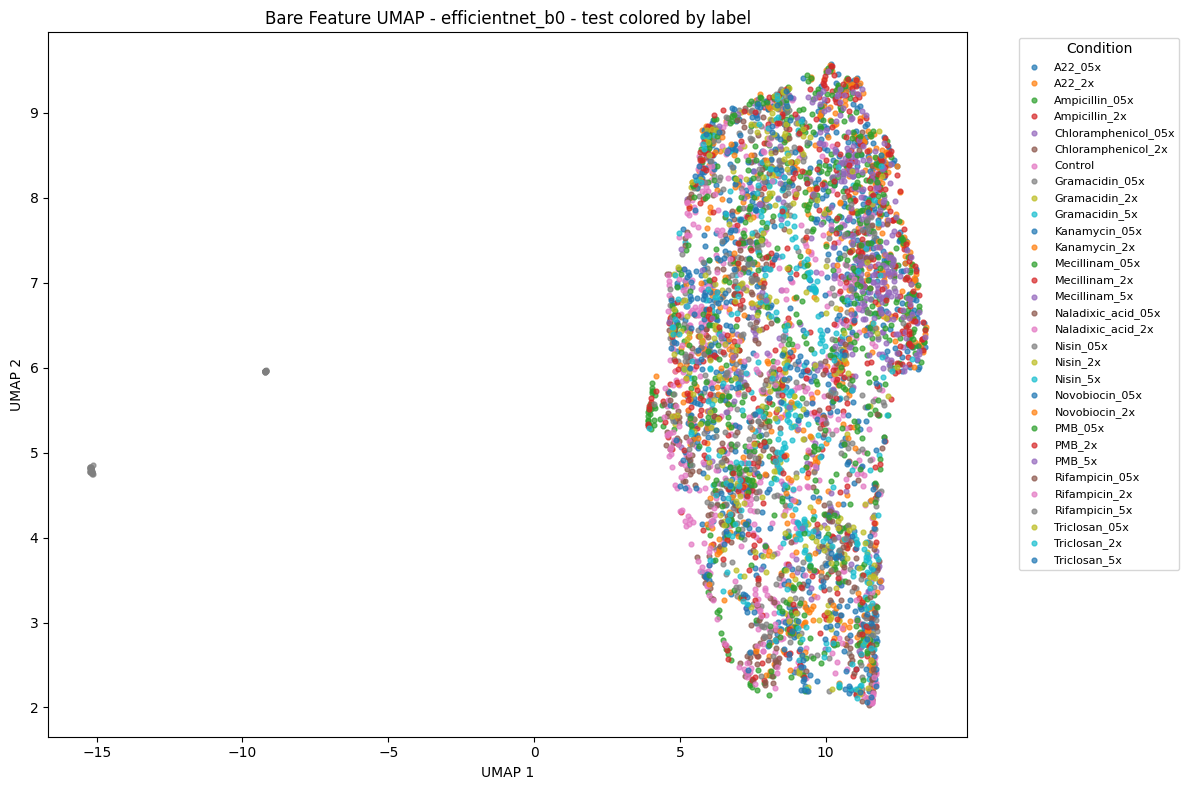


Running bare-feature UMAP for: mobilenet_v3_large
Sampled feature shape: (5000, 3840)
Number of sampled classes: 31
Applied StandardScaler to sampled features.


d:\Haohuan\Anaconda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


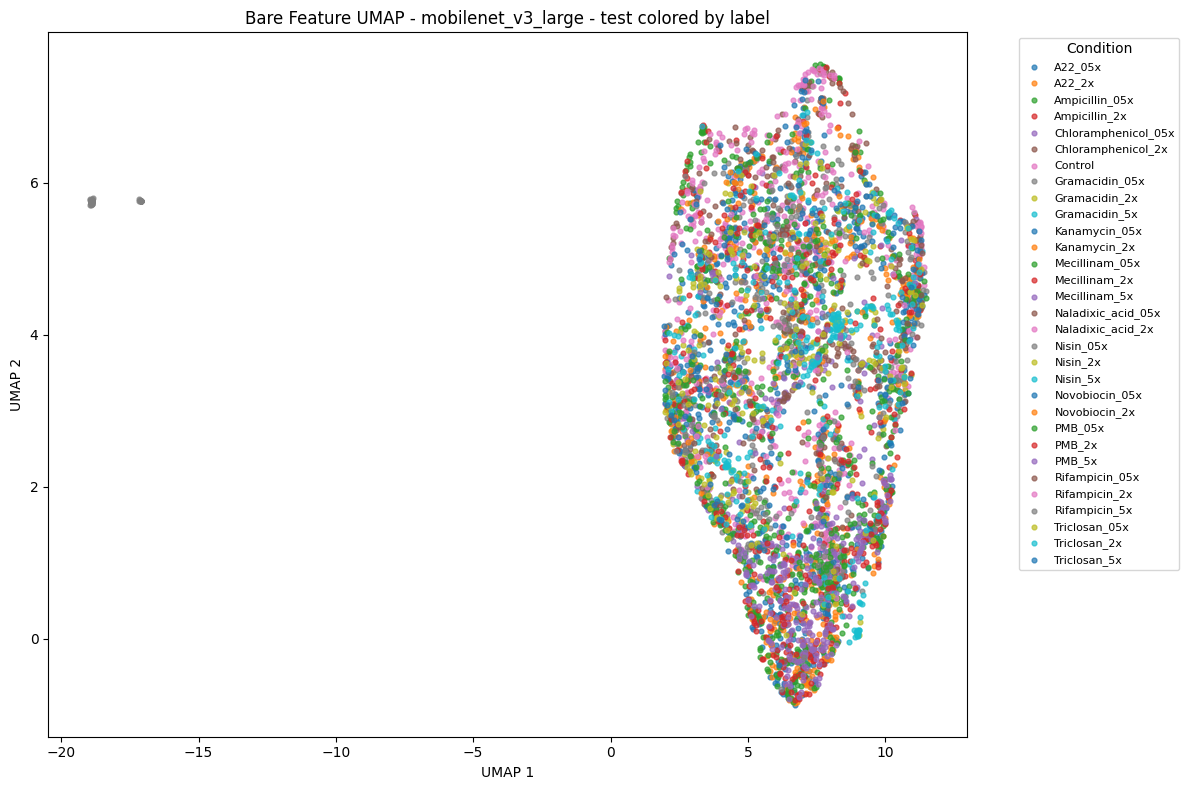


Running bare-feature UMAP for: resnet50
Sampled feature shape: (5000, 8192)
Number of sampled classes: 31
Applied StandardScaler to sampled features.


d:\Haohuan\Anaconda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


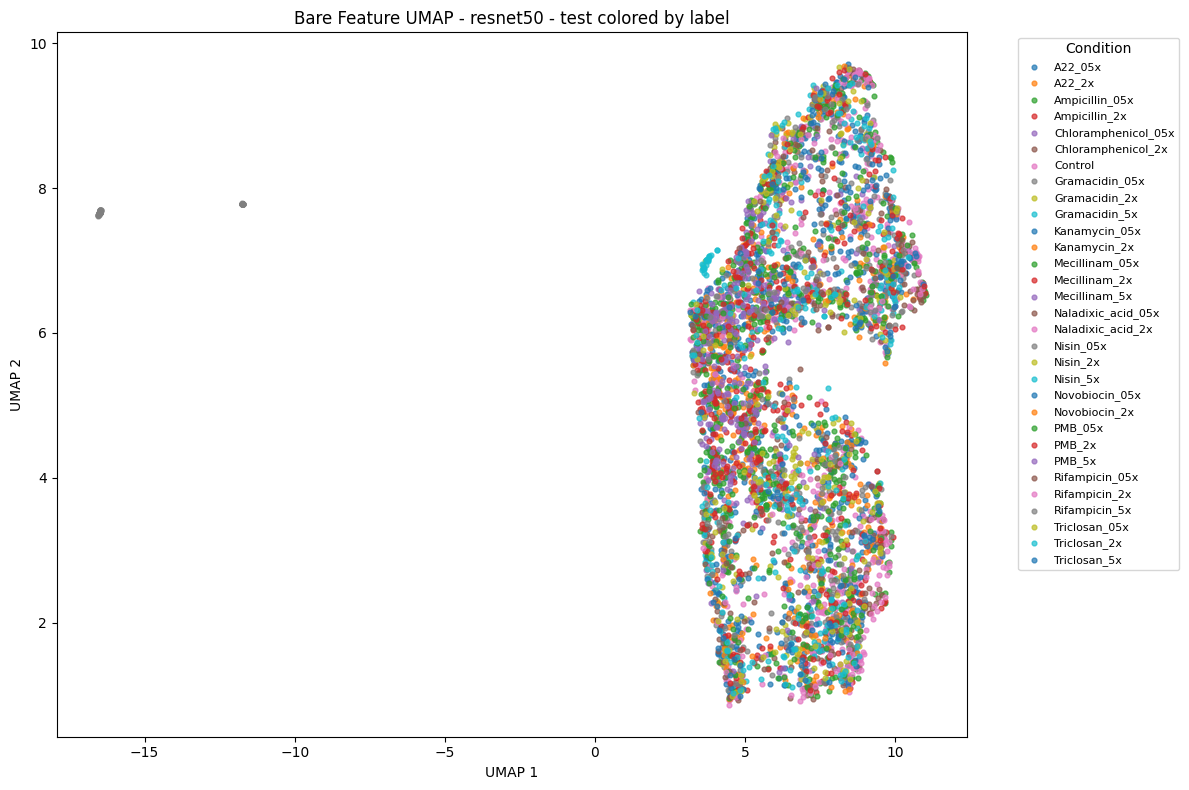


Running bare-feature UMAP for: vit_b_16
Sampled feature shape: (5000, 3072)
Number of sampled classes: 31
Applied StandardScaler to sampled features.


d:\Haohuan\Anaconda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


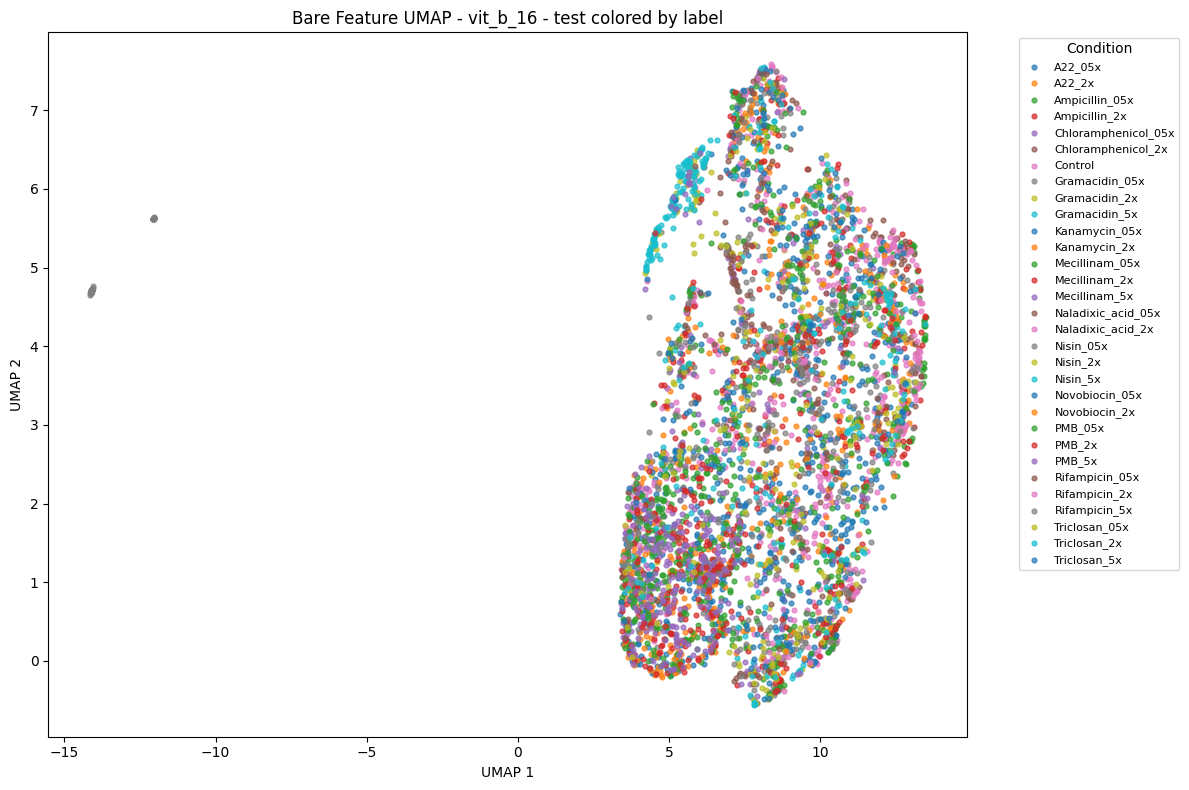

Saved summary to: ..\output\bare_feature_umap_results\summary.csv


,feature_name,source,n_samples,n_classes,result_dir
0,cytoimagenet_efficientnetb0,test,5000,31,..\output\bare_feature_umap_results\cytoimagen...
1,densenet121,test,5000,31,..\output\bare_feature_umap_results\densenet121
2,efficientnet_b0,test,5000,31,..\output\bare_feature_umap_results\efficientn...
3,mobilenet_v3_large,test,5000,31,..\output\bare_feature_umap_results\mobilenet_...
4,resnet50,test,5000,31,..\output\bare_feature_umap_results\resnet50
5,vit_b_16,test,5000,31,..\output\bare_feature_umap_results\vit_b_16


In [14]:
summary_rows = []

for feature_folder in feature_folders:
    summary_row = run_umap_for_feature_folder(
        feature_folder,
        source=VISUALIZATION_SOURCE,
        max_samples=MAX_VIS_SAMPLES,
    )
    summary_rows.append(summary_row)

summary_df = pd.DataFrame(summary_rows)
summary_path = RESULTS_DIR / "summary.csv"
summary_df.to_csv(summary_path, index=False)

print("Saved summary to:", summary_path)
display(summary_df)


In [15]:
# Optional: inspect the generated output files for one feature set.

example_feature = summary_df.iloc[0]["feature_name"]
example_dir = RESULTS_DIR / example_feature

print("Example feature:", example_feature)
print("Output directory:", example_dir)

for path in sorted(example_dir.iterdir()):
    print(path.name)


Example feature: cytoimagenet_efficientnetb0
Output directory: ..\output\bare_feature_umap_results\cytoimagenet_efficientnetb0
bare_features_sample_test.npy
bare_features_umap_test.csv
bare_features_umap_test.npy
bare_features_umap_test_by_label.png


NameError: name 'sampled_labels_idx' is not defined